In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load dataset
df = pd.read_csv("Superstore.csv", encoding="latin1")

print(df.head())
print(df.shape)


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [23]:
print("Business Objective:")
print("To analyze sales, profit, categories, regions and time trends")
print("and identify insights that can support business decision-making.")

Business Objective:
To analyze sales, profit, categories, regions and time trends
and identify insights that can support business decision-making.


In [24]:
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
yearly_data = df.groupby('Year')[['Sales', 'Profit']].sum()
print("\nYearly Sales and Profit:")
print(yearly_data)

print("\nCorrelation:")
print(df[['Sales', 'Profit', 'Discount']].corr())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null  

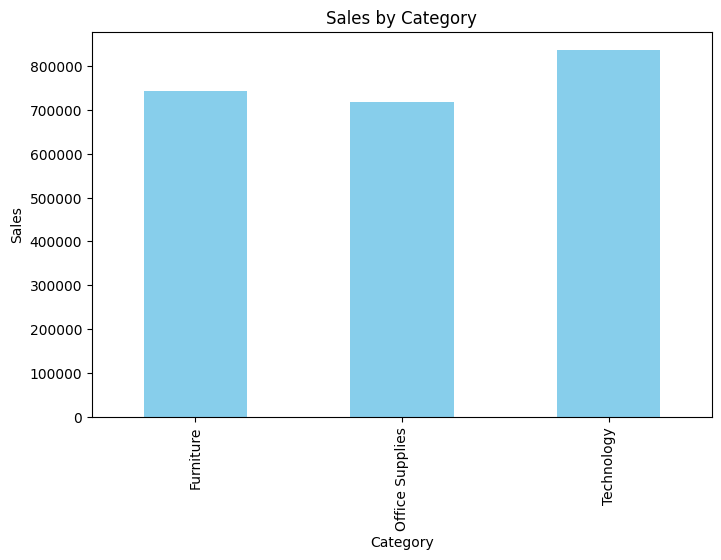

In [25]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='skyblue')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

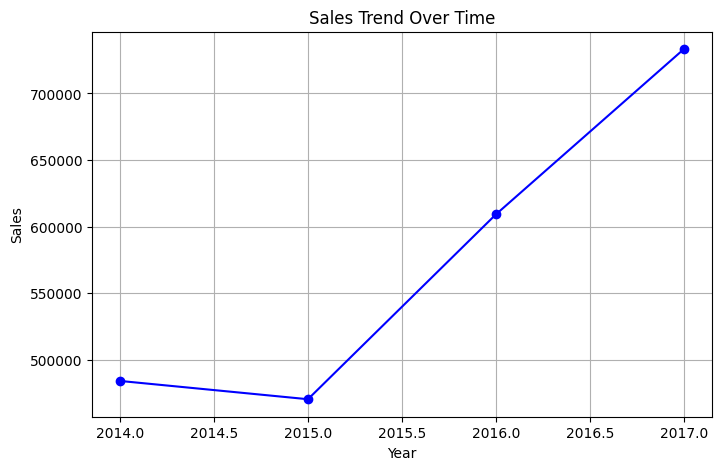

In [26]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values,
         marker='o', color='blue')
plt.title("Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid()
plt.show()


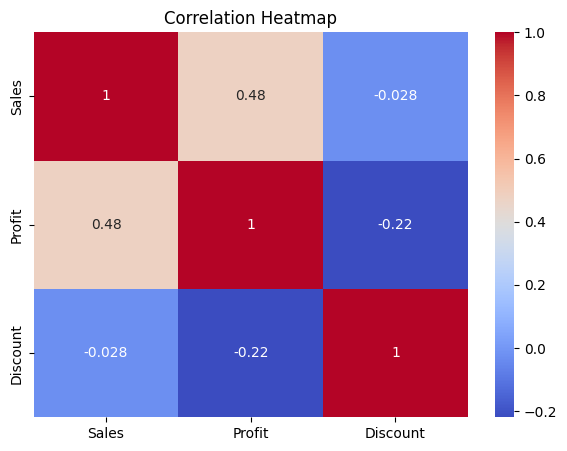

In [27]:
plt.figure(figsize=(7,5))
sns.heatmap(
    df[['Sales', 'Profit', 'Discount']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [28]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
profit_margin = (total_profit / total_sales) * 100

print("\nKey Performance Indicators:")
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Profit Margin:", round(profit_margin, 2), "%")


Key Performance Indicators:
Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Profit Margin: 12.47 %


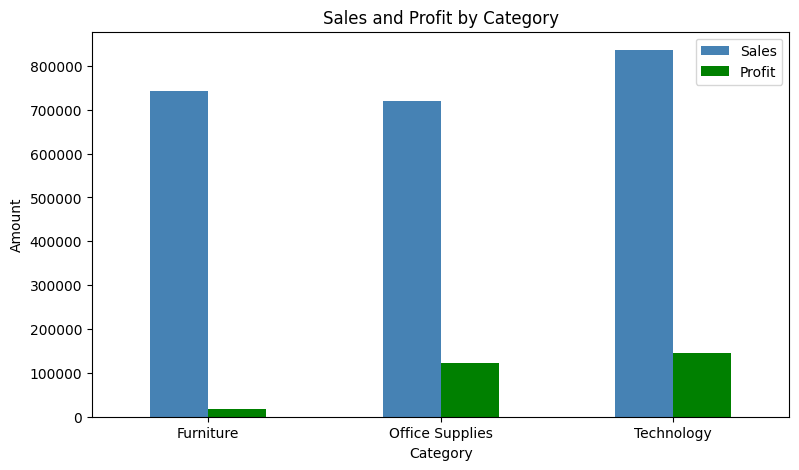

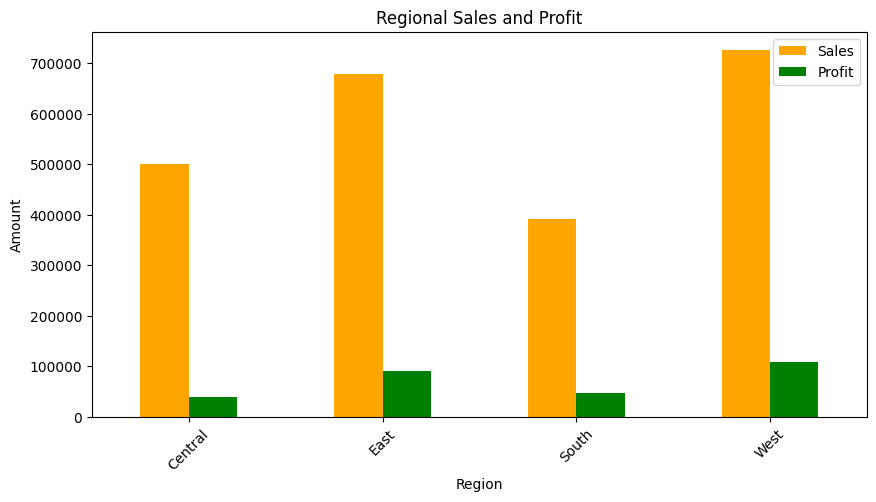

In [29]:
category_data = df.groupby('Category')[['Sales', 'Profit']].sum()

category_data.plot(
    kind='bar',
    figsize=(9,5),
    color=['steelblue', 'green']
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()


region_data = df.groupby('Region')[['Sales', 'Profit']].sum()

region_data.plot(
    kind='bar',
    figsize=(10,5),
    color=['orange', 'green']
)

plt.title("Regional Sales and Profit")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

In [30]:
best_category = category_sales.idxmax()
best_region = df.groupby('Region')['Sales'].sum().idxmax()

print("\nMajor Insights:")
print("1. Highest Sales Category:", best_category)
print("2. Highest Sales Region:", best_region)
print("3. Total Sales:", round(total_sales, 2))
print("4. Total Profit:", round(total_profit, 2))

print("\nOpportunities:")
print("- Focus on high-performing categories and regions.")
print("- Increase sales of profitable products.")

print("\nRisks / Performance Gaps:")
print("- High sales do not always mean high profit.")
print("- Products with low or negative profit should be reviewed.")
print("- Excessive discounts may reduce profitability.")


Major Insights:
1. Highest Sales Category: Technology
2. Highest Sales Region: West
3. Total Sales: 2297200.86
4. Total Profit: 286397.02

Opportunities:
- Focus on high-performing categories and regions.
- Increase sales of profitable products.

Risks / Performance Gaps:
- High sales do not always mean high profit.
- Products with low or negative profit should be reviewed.
- Excessive discounts may reduce profitability.


In [31]:
print("\nActionable Recommendations:")
print("1. Focus marketing on high-profit categories.")
print("2. Review pricing and discounts for low-profit products.")
print("3. Improve strategies in underperforming regions.")
print("4. Maintain sufficient inventory for high-demand products.")
print("5. Use sales trends for future planning and forecasting.")



Actionable Recommendations:
1. Focus marketing on high-profit categories.
2. Review pricing and discounts for low-profit products.
3. Improve strategies in underperforming regions.
4. Maintain sufficient inventory for high-demand products.
5. Use sales trends for future planning and forecasting.


In [32]:
fig = px.scatter(
    df,
    x='Sales',
    y='Profit',
    color='Category',
    hover_data=['Product Name', 'Region'],
    title='Interactive Sales vs Profit Analysis'
)

fig.show()

In [33]:
print("""
Data storytelling converts complex data into clear visual insights.
It helps business stakeholders understand trends, performance,
opportunities, risks, and recommendations quickly.

By combining data, visualizations, and a clear narrative,
analysts can communicate findings effectively and support
better data-driven business decisions.
""")


Data storytelling converts complex data into clear visual insights.
It helps business stakeholders understand trends, performance,
opportunities, risks, and recommendations quickly.

By combining data, visualizations, and a clear narrative,
analysts can communicate findings effectively and support
better data-driven business decisions.

